# Sentiment Analysis Using Deep Learning (LSTM)

## Project Category
Natural Language Processing (NLP) / Deep Learning

---

## Objective

The objective of this project is to classify text sentiments as positive or negative using deep learning techniques.

This project aims to:
- preprocess text data,
- tokenize textual information,
- apply word embeddings,
- build an LSTM neural network,
- and perform sentiment classification.

---

## Dataset Information

The dataset contains textual reviews labeled with sentiment categories such as:

- Positive
- Negative

The dataset is used for natural language processing and text classification tasks.

### Dataset Link

https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

---

## Techniques Used

- Text Cleaning
- Tokenization
- Padding
- Word Embedding
- LSTM (Long Short-Term Memory)
- Deep Learning
- Text Classification

---

## Libraries Used

- TensorFlow / Keras
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

---

## Project Workflow

1. Data Loading
2. Text Preprocessing
3. Tokenization
4. Sequence Padding
5. Train-Test Split
6. LSTM Model Building
7. Model Training
8. Model Evaluation
9. Sentiment Prediction
10. Conclusion

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Data Types:
review       object
sentiment    object
dtype: object

Missing Values:
review       0
sentiment    0
dtype: int64

Duplicate Rows:
418


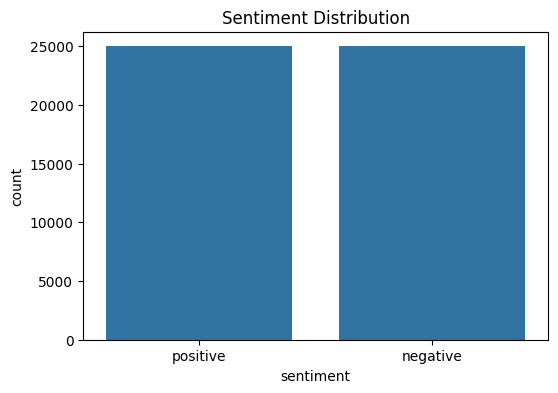

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=df["sentiment"])

plt.title("Sentiment Distribution")

plt.show()

In [ ]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0})

In [ ]:
df["Review_Length"] = df["review"].apply(len)

df[["review", "sentiment", "Review_Length"]].head()

,review,sentiment,Review_Length
0,One of the other reviewers has mentioned that ...,1,1761
1,A wonderful little production. <br /><br />The...,1,998
2,I thought this was a wonderful way to spend ti...,1,926
3,Basically there's a family where a little boy ...,0,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317


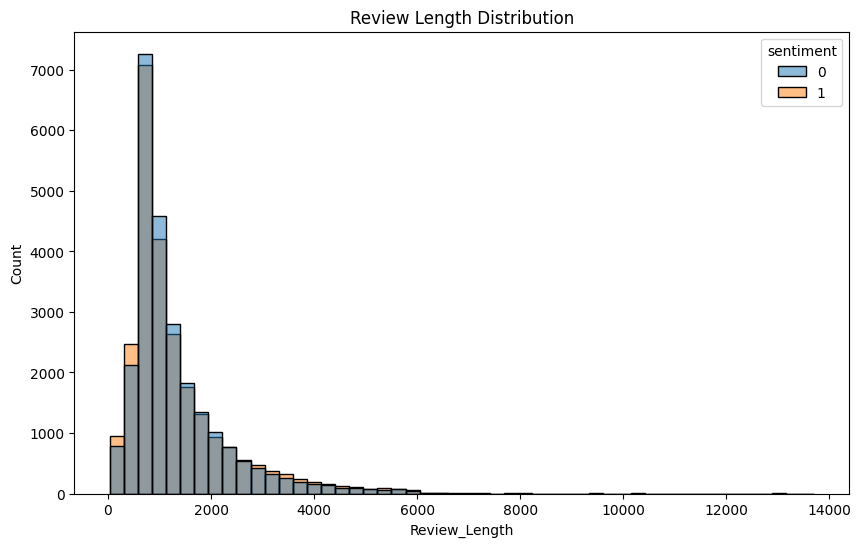

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Review_Length",
    hue="sentiment",
    bins=50)

plt.title("Review Length Distribution")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df["review"]

y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
### TOKENIZATION
from tensorflow.keras.preprocessing.text import Tokenizer

max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words)

tokenizer.fit_on_texts(X_train)

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len)

### LTSM MODEL

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout)

In [ ]:
model = Sequential()

model.add(Embedding(input_dim=max_words,output_dim=128))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5058 - loss: 0.6932
Test Loss: 0.6932035684585571
Test Accuracy: 0.5058000087738037


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
1,25000
0,25000


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128))

model.add(Bidirectional(LSTM(64)))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.7837 - loss: 0.4422 - val_accuracy: 0.8690 - val_loss: 0.3227
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9044 - loss: 0.2520 - val_accuracy: 0.8756 - val_loss: 0.2989
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9263 - loss: 0.1988 - val_accuracy: 0.8791 - val_loss: 0.3299
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9420 - loss: 0.1579 - val_accuracy: 0.8760 - val_loss: 0.3258
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9564 - loss: 0.1211 - val_accuracy: 0.8731 - val_loss: 0.3519


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8775 - loss: 0.3243
Test Loss: 0.3242506682872772
Test Accuracy: 0.8774999976158142


In [ ]:
y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


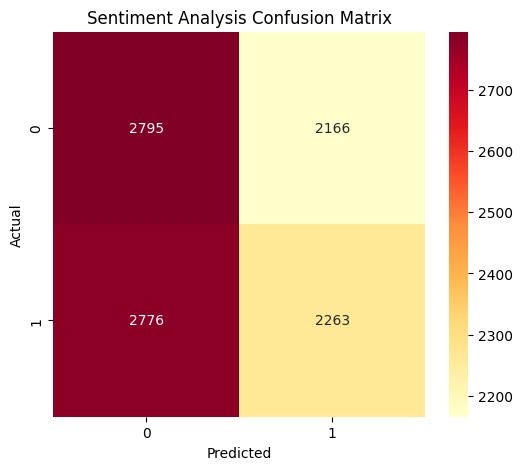

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    y_test,
    y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Sentiment Analysis Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.56      0.53      4961
           1       0.51      0.45      0.48      5039

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



In [ ]:
max_words = 20000
max_len = 300

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model = Sequential()

model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128 ))

model.add(
    Bidirectional(LSTM(128)))

model.add(Dropout(0.5))

model.add(Dense(64, activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"])

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.7773 - loss: 0.4490 - val_accuracy: 0.8626 - val_loss: 0.3367
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8977 - loss: 0.2693 - val_accuracy: 0.8702 - val_loss: 0.3205
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9251 - loss: 0.1993 - val_accuracy: 0.8752 - val_loss: 0.3380
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9443 - loss: 0.1541 - val_accuracy: 0.8719 - val_loss: 0.3808
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9573 - loss: 0.1218 - val_accuracy: 0.8650 - val_loss: 0.3805


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8822 - loss: 0.3053
Test Loss: 0.30532148480415344
Test Accuracy: 0.8822000026702881


In [ ]:
y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


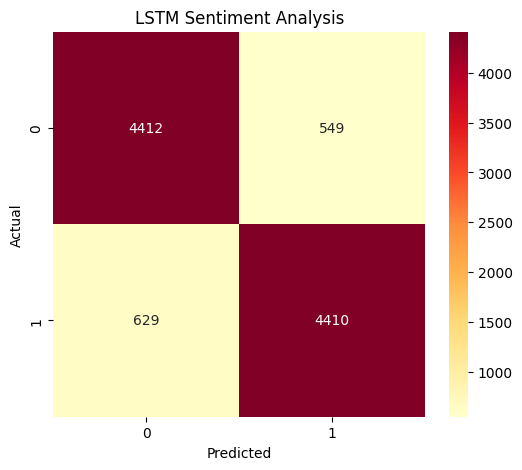

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(
    y_test,
    y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "LSTM Sentiment Analysis")

plt.show()

## Conclusion

A deep learning-based sentiment analysis system was successfully developed using IMDb movie reviews.

The project applied:
- text preprocessing,
- tokenization,
- sequence padding,
- word embeddings,
- and Bidirectional LSTM neural networks

to classify movie reviews as positive or negative.

The final model achieved approximately 88% test accuracy and demonstrated strong sentiment classification capability.

The project showed the effectiveness of deep learning techniques for:
- natural language processing,
- text classification,
- and sentiment analysis tasks.

This project also provided practical experience in:
- NLP preprocessing,
- sequence modeling,
- LSTM architectures,
- and deep learning-based language understanding.